<a href="https://colab.research.google.com/github/Tehila-BD/cloud-computing/blob/main/Tutorial5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install requests beautifulsoup4

import requests
from bs4 import BeautifulSoup
import re

# Link to the website about plant disease (Grapevine Anthracnose)
url = "https://en.wikipedia.org/wiki/Elsino%C3%AB_ampelina"

def fetch_page(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return BeautifulSoup(response.text, "html.parser")
    return None

# Activate the scan function
soup = fetch_page(url)
if soup:
    raw_text = soup.get_text()
    print("The site was successfully scanned! The text was saved in memory.")
else:
    print("Error crawling the site.")

The site was successfully scanned! The text was saved in memory.


In [2]:
!pip install nltk
import nltk
from nltk.stem import PorterStemmer

#10 The words we chose
chosen_words = ['disease', 'grape', 'lesion', 'leaf', 'plant', 'spore', 'vine', 'infection', 'symptom', 'fruit']

stemmer = PorterStemmer()

# Performing stemming for our words
target_keywords = [stemmer.stem(w) for w in chosen_words]

print("Our 10 words after stemming:")
print(target_keywords)

Our 10 words after stemming:
['diseas', 'grape', 'lesion', 'leaf', 'plant', 'spore', 'vine', 'infect', 'symptom', 'fruit']


In [3]:
def index_words(text):
    index = {}
    words = re.findall(r'\w+', text)
    for word in words:
        word = word.lower()
        index[word] = index.get(word, 0) + 1
    return index

def remove_stop_words(index):
    stop_words = {'a', 'an', 'the', 'and', 'or', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'is', 'by', 'as', 'this', 'are', 'from', 'it'}
    for stop_word in stop_words:
        if stop_word in index:
            del index[stop_word]
    return index

def apply_stemming(index):
    stemmer = PorterStemmer()
    stemmed_index = {}
    for word, count in index.items():
        stemmed_word = stemmer.stem(word)
        stemmed_index[stemmed_word] = stemmed_index.get(stemmed_word, 0) + count
    return stemmed_index

# Processing all text
raw_index = index_words(raw_text)
clean_index = remove_stop_words(raw_index)
final_index = apply_stemming(clean_index)

# Create the final index that contains only the frequency of our 10 words
project_index = {word: final_index.get(word, 0) for word in target_keywords}

print("Frequency index for the 10 words we chose:")
print(project_index)

Frequency index for the 10 words we chose:
{'diseas': 26, 'grape': 42, 'lesion': 19, 'leaf': 3, 'plant': 20, 'spore': 1, 'vine': 9, 'infect': 18, 'symptom': 4, 'fruit': 5}


In [7]:
!pip install firebase-admin
import firebase_admin
from firebase_admin import credentials, db

cred = credentials.Certificate("/content/tutorial5.json")

if not firebase_admin._apps:
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'https://tutorial5-24597-default-rtdb.firebaseio.com/'
    })

# Saving the information in the DB
ref = db.reference('plant_disease_exercise')
ref.set({
    "url": url,
    "words_index": project_index
})

print("The index and website link have been successfully saved to Firebase!")

The index and website link have been successfully saved to Firebase!


The source that was scanned: https://en.wikipedia.org/wiki/Elsino%C3%AB_ampelina

Number of occurrences per word:
- The word 'diseas' appears 26 times.
- The word 'fruit' appears 5 times.
- The word 'grape' appears 42 times.
- The word 'infect' appears 18 times.
- The word 'leaf' appears 3 times.
- The word 'lesion' appears 19 times.
- The word 'plant' appears 20 times.
- The word 'spore' appears 1 times.
- The word 'symptom' appears 4 times.
- The word 'vine' appears 9 times.


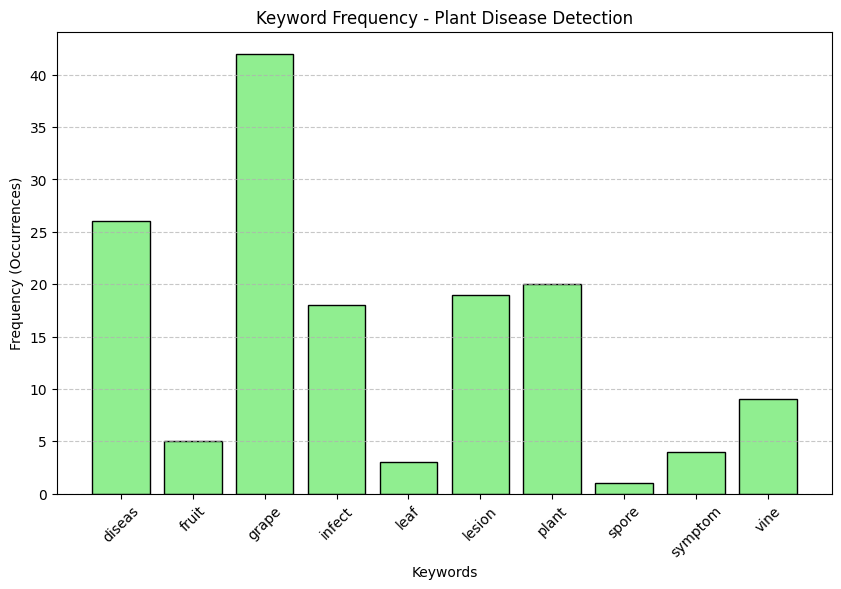

In [8]:
import matplotlib.pyplot as plt

# Retrieving data from Firebase
retrieved_data = ref.get()
db_url = retrieved_data['url']
db_index = retrieved_data['words_index']

# Print the link and words
print(f"The source that was scanned: {db_url}\n")
print("Number of occurrences per word:")
for word, count in db_index.items():
    print(f"- The word '{word}' appears {count} times.")

# Creating the Chart
words = list(db_index.keys())
counts = list(db_index.values())

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='lightgreen', edgecolor='black')

plt.xlabel('Keywords')
plt.ylabel('Frequency (Occurrences)')
plt.title('Keyword Frequency - Plant Disease Detection')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display
plt.show()